# Swedish Industrial Air Emissions Analysis

Analysis of facility-level E-PRTR air releases in Sweden from 2018 to 2024.

**Data source:** European Environment Agency  
**Unit:** kg/year  
**Focus:** emission trends, data availability, major CO₂ emitters, sector contributions, and spatial distribution

## 1. Setup and Data Loading

### Reproducibility and software requirements

This notebook provides a reproducible workflow for analysing facility-level industrial air emissions reported in Sweden under the European Pollutant Release and Transfer Register.

Instructions for setting up and running the workflow are provides in the repository 'README.md', while data provenance and download instructions are documented in 'DATA.md'. software dependences are 'specified in 'requirements.txt'.

### Version pinning strategy

I use bounded version ranges rather than leaving package versions completely unrestricted. For example, 'pandas>=2.0,<3.0' means that pandas version 2.0 or later can be used, but version 3.0 or later will not be installed.

### Risk assessment for future package breaking

Major version upadating is the main risk, whch are more likely to introduce breaking changes. Minor or patch updates are generally lower risk, but they may still change plotting behaviour, data types, warnings, or numberical results.

If the dependencies are updates in the future, the workflow should be tested again to ensure that the notebook and the analysis script still run correctly and produce consistent results. If an incompatibility is found, the affected dependency can be restricted to a narrower version range or pinned to a know working version.

In [3]:
from pathlib import Path

import pandas as pd


In [2]:
air_file=(
    Path.cwd()
    /'EEA_Industry_Dataset_EPRTR_Air_Releases.xlsx'
)

print('File Path:',air_file)
print('File exist:',air_file.exists())

File Path: /Users/zaochen/Documents/swedish_industrial_emissions_analysis/EEA_Industry_Dataset_EPRTR_Air_Releases.xlsx
File exist: True


## 2. Initial Data Exploration

The dataset structure, available worksheets, columns, pollutants, years, and Swedish facility records are examined.

In [3]:
air_excel=pd.ExcelFile(air_file)

print('Sheet names:')
for sheet_name in air_excel.sheet_names:
    print('-',sheet_name)

Sheet names:
- Air_Releases_National
- Air_Releases_Sector
- Air_Releases_AnnexIActivity
- Air_Releases_Facilities


In [4]:
air_raw=pd.read_excel(
    air_file,
    sheet_name="Air_Releases_Facilities"
    )

print('Data shape:',air_raw.shape)
air_raw.head()

Data shape: (53330, 29)


,PublicationDate,countryName,EPRTRAnnexIMainActivity,FacilityInspireId,facilityName,city,Longitude,Latitude,addressConfidentialityReason,TargetRelease,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,2025/12/15,Greece,3(c)(i),EL.CAED/100076.FACILITY,TITAN CEMENT S.A. - KAMARI PLANT,"KAMARI, DERVENOCHORIA",23.524580,38.130180,NaN,AIR,...,101000.0,81700.0,59500.0,46800.0,46200.0,39500.0,75000.0,69200.0,4.280000e+04,42900.000
1,2025/12/15,Poland,5(d),PL.EEA/05E001743.FACILITY,Przedsiębiorstwo Komunalne SANIKOM Sp. z o.o. ...,Wola Kruszyńska,19.269890,51.414250,NaN,AIR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025/12/15,Portugal,7(a)(i),PT.CAED/PT.APA05774662.CI,Instalação Avícola da Quinta das Sesmarias (CI),BENAVENTE,-8.771258,38.918404,NaN,AIR,...,15500.0,16100.0,16900.0,23500.0,23100.0,24200.0,27600.0,21300.0,2.610000e+04,24200.000
3,2025/12/15,Spain,2(e)(ii),ES.CAED/008593000.FACILITY,ALTUNA METAL WORKS,ARETXABALETA,-2.505515,43.029334,NaN,AIR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.230000e-01,0.523
4,2025/12/15,Germany,5(b),https://registry.gdi-de.org/id/de.by.inspire.p...,Abfallheizkraftwerk Geiselbullach,Olching,11.359532,48.235328,NaN,AIR,...,62200000.0,60600000.0,NaN,61500000.0,NaN,NaN,68200000.0,69200000.0,7.030000e+07,NaN


In [5]:
print('Column name:')

for column in air_raw.columns:
    print('-',column)

Column name:
- PublicationDate
- countryName
- EPRTRAnnexIMainActivity
- FacilityInspireId
- facilityName
- city
- Longitude
- Latitude
- addressConfidentialityReason
- TargetRelease
- Pollutant
- 2007
- 2008
- 2009
- 2010
- 2011
- 2012
- 2013
- 2014
- 2015
- 2016
- 2017
- 2018
- 2019
- 2020
- 2021
- 2022
- 2023
- 2024


In [6]:
Sweden_raw=air_raw[
    air_raw['countryName']=='Sweden'
].copy()

print('Sweden data shape:',Sweden_raw.shape)
print('Number of facilities:',Sweden_raw['FacilityInspireId'].nunique())

Sweden_raw.head()

Sweden data shape: (1104, 29)
Number of facilities: 407


,PublicationDate,countryName,EPRTRAnnexIMainActivity,FacilityInspireId,facilityName,city,Longitude,Latitude,addressConfidentialityReason,TargetRelease,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
37,2025/12/15,Sweden,2(b),SE.CAED/10017901.Facility,Höganäs Sweden AB,HÖGANÄS,12.54737,56.20871,NaN,AIR,...,1.970000e+08,1.890000e+08,1.970000e+08,2.020000e+08,1.730000e+08,1.660000e+08,2.020000e+08,1.760000e+08,1.494210e+08,1.532910e+08
40,2025/12/15,Sweden,5(b),SE.CAED/10017666.Facility,Sysavs avfallsförbränningsanläggning,MALMÖ,13.04528,55.63196,NaN,AIR,...,1.770000e+04,1.250000e+04,1.240000e+04,1.110000e+04,1.450000e+04,1.380000e+04,1.240000e+04,1.260000e+04,NaN,NaN
339,2025/12/15,Sweden,2(e)(i),SE.CAED/10023940.Facility,Rönnskärsverken,SKELLEFTEHAMN,21.26869,64.66810,NaN,AIR,...,2.280000e+02,2.110000e+02,2.700000e+02,2.200000e+02,2.270000e+02,2.000000e+02,1.010000e+02,1.200000e+02,1.360000e+02,2.155000e+02
342,2025/12/15,Sweden,3(c),SE.CAED/10016795.Facility,"Heidelberg Materials Cement Sverige AB, Slitef...",SLITE,18.80539,57.71172,NaN,AIR,...,1.760000e+09,1.740000e+09,1.600000e+09,1.530000e+09,1.360000e+09,1.460000e+09,1.440000e+09,1.360000e+09,1.337734e+09,1.251990e+09
377,2025/12/15,Sweden,5(b),SE.CAED/10019386.Facility,Sävenäs,GÖTEBORG,12.05243,57.73201,NaN,AIR,...,1.660000e+02,NaN,NaN,NaN,NaN,5.600000e+01,NaN,NaN,NaN,NaN


In [7]:
pollutants=sorted(
   Sweden_raw['Pollutant'].dropna().unique() 
)

print('number of pollutants:',len(pollutants))

for pollutant in pollutants:
    print('-',pollutant)

number of pollutants: 37
- 1,2-dichloroethane (DCE-1,2)
- Ammonia (NH3)
- Anthracene
- Arsenic and compounds (as As)
- Benzene
- Cadmium and compounds (as Cd)
- Carbon dioxide (CO2)
- Carbon dioxide (CO2) excluding biomass
- Carbon monoxide (CO)
- Chlorine and inorganic compounds (as HCl)
- Chlorofluorocarbons (CFCs)
- Chromium and compounds (as Cr)
- Copper and compounds (as Cu)
- Di-(2-ethyl hexyl) phthalate (DEHP)
- Dichloromethane (DCM)
- Fluorine and inorganic compounds (as HF)
- Halons
- Hydro-fluorocarbons (HFCS)
- Hydrochlorofluorocarbons (HCFCs)
- Lead and compounds (as Pb)
- Mercury and compounds (as Hg)
- Methane (CH4)
- Naphthalene
- Nickel and compounds (as Ni)
- Nitrogen oxides (NOX)
- Nitrous oxide (N2O)
- Non-methane volatile organic compounds (NMVOC)
- PCDD + PCDF (dioxins + furans) (as Teq)
- Particulate matter (PM10)
- Perfluorocarbons (PFCs)
- Polycyclic aromatic hydrocarbons (PAHs)
- Sulphur hexafluoride (SF6)
- Sulphur oxides (SOX)
- Trichloroethylene (TRI)
- Tric

In [8]:
print('Recent year columns:')

for column in Sweden_raw.columns[-7:]:
    print(repr(column),'-',type(column).__name__)

Recent year columns:
'2018' - str
'2019' - str
'2020' - str
'2021' - str
'2022' - str
'2023' - str
'2024' - str


## 3. Data Reshaping and Cleaning

Annual columns are converted from wide to long format. Year and emission fields are cleaned and prepared for analysis.

In [9]:
recent_years = [
    "2018",
    "2019",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024"
]

id_columns = [
    "FacilityInspireId",
    "facilityName",
    "city",
    "Longitude",
    "Latitude",
    "EPRTRAnnexIMainActivity",
    "TargetRelease",
    "Pollutant"
]

sweden_long = Sweden_raw.melt(
    id_vars=id_columns,
    value_vars=recent_years,
    var_name="Year",
    value_name="Emission"
)

print("Long-format shape:", sweden_long.shape)
sweden_long.head(10)

Long-format shape: (7728, 10)


,FacilityInspireId,facilityName,city,Longitude,Latitude,EPRTRAnnexIMainActivity,TargetRelease,Pollutant,Year,Emission
0,SE.CAED/10017901.Facility,Höganäs Sweden AB,HÖGANÄS,12.54737,56.20871,2(b),AIR,Carbon dioxide (CO2),2018,2.020000e+08
1,SE.CAED/10017666.Facility,Sysavs avfallsförbränningsanläggning,MALMÖ,13.04528,55.63196,5(b),AIR,Ammonia (NH3),2018,1.110000e+04
2,SE.CAED/10023940.Facility,Rönnskärsverken,SKELLEFTEHAMN,21.26869,64.66810,2(e)(i),AIR,Arsenic and compounds (as As),2018,2.200000e+02
3,SE.CAED/10016795.Facility,"Heidelberg Materials Cement Sverige AB, Slitef...",SLITE,18.80539,57.71172,3(c),AIR,Carbon dioxide (CO2) excluding biomass,2018,1.530000e+09
4,SE.CAED/10019386.Facility,Sävenäs,GÖTEBORG,12.05243,57.73201,5(b),AIR,Nickel and compounds (as Ni),2018,NaN
5,SE.CAED/10017896.Facility,Skåneägg Produktion AB,MÖRARP,12.84955,56.05316,7(a)(i),AIR,Ammonia (NH3),2018,1.860000e+04
6,SE.CAED/10021916.Facility,"Ovako Sweden AB, Hofors",HOFORS,16.30633,60.55353,2(b),AIR,Zinc and compounds (as Zn),2018,1.680000e+03
7,SE.CAED/10016548.Facility,Applerum,VASSMOLÖSA,16.09401,56.57507,7(a)(i),AIR,Ammonia (NH3),2018,NaN
8,SE.CAED/10014311.Facility,Skutskärs Bruk,SKUTSKÄR,17.38983,60.64365,6(a),AIR,Carbon dioxide (CO2) excluding biomass,2018,6.560000e+05
9,SE.CAED/10020475.Facility,Hedenverket,KARLSTAD,13.57206,59.38647,1(c),AIR,PCDD + PCDF (dioxins + furans) (as Teq),2018,NaN


## 4. Availability of Reported Values

The analysis evaluates the proportion of facility–pollutant records with reported annual values.

A blank value does not necessarily indicate missing or non-compliant reporting because releases below E-PRTR thresholds may not be reported.

In [10]:
year_quality=(
    sweden_long
    .groupby('Year')['Emission']
    .agg(
        total_rows='size',
        reported_values='count',
        missing_values=lambda values:values.isna().sum()
    )
)

year_quality

,total_rows,reported_values,missing_values
Year,,,
2018,1104,579,525
2019,1104,552,552
2020,1104,522,582
2021,1104,558,546
2022,1104,530,574
2023,1104,466,638
2024,1104,448,656


In [11]:
year_quality['reporting_rate_pct']=(
    year_quality['reported_values']/
    year_quality['total_rows']
    *100
).round(1)

year_quality

,total_rows,reported_values,missing_values,reporting_rate_pct
Year,,,,
2018,1104,579,525,52.4
2019,1104,552,552,50.0
2020,1104,522,582,47.3
2021,1104,558,546,50.5
2022,1104,530,574,48.0
2023,1104,466,638,42.2
2024,1104,448,656,40.6


In [12]:
focus_pollutants = [
    "Carbon dioxide (CO2) excluding biomass",
    "Ammonia (NH3)",
    "Nitrogen oxides (NOX)",
    "Nitrous oxide (N2O)",
    "Non-methane volatile organic compounds (NMVOC)",
    "Particulate matter (PM10)"
]

focus_data = sweden_long[
    sweden_long["Pollutant"].isin(focus_pollutants)
].copy()

print("Focus data shape:", focus_data.shape)
print("Pollutants found:", focus_data["Pollutant"].nunique())

focus_data["Pollutant"].value_counts()

Focus data shape: (4088, 10)
Pollutants found: 6


Pollutant
Ammonia (NH3)                                     1561
Carbon dioxide (CO2) excluding biomass             847
Nitrogen oxides (NOX)                              742
Nitrous oxide (N2O)                                378
Non-methane volatile organic compounds (NMVOC)     322
Particulate matter (PM10)                          238
Name: count, dtype: int64

In [13]:
pollutant_year_quality=(
    focus_data.groupby(['Pollutant','Year'])['Emission']
    .agg(
        total_rows='size',
        reported_values='count'
    )
    .reset_index()
)

pollutant_year_quality['reporting_rate_pct']=(
    pollutant_year_quality['reported_values']/
    pollutant_year_quality['total_rows']
    *100
).round(1)

pollutant_year_quality.head(14)

,Pollutant,Year,total_rows,reported_values,reporting_rate_pct
0,Ammonia (NH3),2018,223,89,39.9
1,Ammonia (NH3),2019,223,76,34.1
2,Ammonia (NH3),2020,223,76,34.1
3,Ammonia (NH3),2021,223,74,33.2
4,Ammonia (NH3),2022,223,66,29.6
5,Ammonia (NH3),2023,223,48,21.5
6,Ammonia (NH3),2024,223,47,21.1
7,Carbon dioxide (CO2) excluding biomass,2018,121,95,78.5
8,Carbon dioxide (CO2) excluding biomass,2019,121,90,74.4
9,Carbon dioxide (CO2) excluding biomass,2020,121,82,67.8


In [14]:
coverage_matrix=pollutant_year_quality.pivot(
    index='Pollutant',
    columns='Year',
    values='reporting_rate_pct'
)

coverage_matrix

Year,2018,2019,2020,2021,2022,2023,2024
Pollutant,,,,,,,
Ammonia (NH3),39.9,34.1,34.1,33.2,29.6,21.5,21.1
Carbon dioxide (CO2) excluding biomass,78.5,74.4,67.8,73.6,69.4,70.2,71.9
Nitrogen oxides (NOX),65.1,64.2,51.9,67.0,63.2,53.8,50.9
Nitrous oxide (N2O),59.3,57.4,51.9,51.9,51.9,50.0,38.9
Non-methane volatile organic compounds (NMVOC),73.9,71.7,73.9,69.6,67.4,65.2,63.0
Particulate matter (PM10),67.6,67.6,61.8,67.6,70.6,47.1,47.1


In [15]:
analysis_data=focus_data.copy()
analysis_data['Year']=analysis_data['Year'].astype(int)
analysis_data['Emission']=pd.to_numeric(
    analysis_data['Emission'],
    errors='coerce')

analysis_data=analysis_data.dropna(
    subset=['Emission']
).copy()

print('Analysis data shape:',analysis_data.shape)
print('Missing emissions:',analysis_data['Emission'].isna().sum())
print('Enative emissions:',(analysis_data['Emission']<0).sum())
print('Zero emissions:',(analysis_data['Emission']==0).sum())

analysis_data.head()



Analysis data shape: (2093, 10)
Missing emissions: 0
Enative emissions: 0
Zero emissions: 0


,FacilityInspireId,facilityName,city,Longitude,Latitude,EPRTRAnnexIMainActivity,TargetRelease,Pollutant,Year,Emission
1,SE.CAED/10017666.Facility,Sysavs avfallsförbränningsanläggning,MALMÖ,13.04528,55.63196,5(b),AIR,Ammonia (NH3),2018,1.110000e+04
3,SE.CAED/10016795.Facility,"Heidelberg Materials Cement Sverige AB, Slitef...",SLITE,18.80539,57.71172,3(c),AIR,Carbon dioxide (CO2) excluding biomass,2018,1.530000e+09
5,SE.CAED/10017896.Facility,Skåneägg Produktion AB,MÖRARP,12.84955,56.05316,7(a)(i),AIR,Ammonia (NH3),2018,1.860000e+04
8,SE.CAED/10014311.Facility,Skutskärs Bruk,SKUTSKÄR,17.38983,60.64365,6(a),AIR,Carbon dioxide (CO2) excluding biomass,2018,6.560000e+05
11,SE.CAED/10014311.Facility,Skutskärs Bruk,SKUTSKÄR,17.38983,60.64365,6(a),AIR,Nitrogen oxides (NOX),2018,7.430000e+05


## 5. Consistent Reporter Trend Analysis

To improve year-to-year comparability, a consistent panel is created using facility–pollutant combinations with reported values in every year from 2018 to 2024.

Emission trends are indexed to 2018 = 100.

In [16]:
facility_year_counts = (
    analysis_data
    .groupby(["Pollutant", "FacilityInspireId"])["Year"]
    .nunique()
    .reset_index(name="years_reported")
)

consistent_facilities = facility_year_counts[
    facility_year_counts["years_reported"] == 7
].copy()

consistent_counts = (
    consistent_facilities
    .groupby("Pollutant")["FacilityInspireId"]
    .nunique()
    .sort_values(ascending=False)
)

consistent_counts

Pollutant
Carbon dioxide (CO2) excluding biomass            73
Nitrogen oxides (NOX)                             50
Ammonia (NH3)                                     33
Non-methane volatile organic compounds (NMVOC)    27
Nitrous oxide (N2O)                               20
Particulate matter (PM10)                         11
Name: FacilityInspireId, dtype: int64

In [17]:
consistent_data = analysis_data.merge(
    consistent_facilities[
        ["Pollutant", "FacilityInspireId"]
    ],
    on=["Pollutant", "FacilityInspireId"],
    how="inner"
)

print("Consistent data shape:", consistent_data.shape)

print(
    "Number of pollutant-facility combinations:",
    consistent_data[
        ["Pollutant", "FacilityInspireId"]
    ].drop_duplicates().shape[0]
)

consistent_data.head()

Consistent data shape: (1498, 10)
Number of pollutant-facility combinations: 214


,FacilityInspireId,facilityName,city,Longitude,Latitude,EPRTRAnnexIMainActivity,TargetRelease,Pollutant,Year,Emission
0,SE.CAED/10016795.Facility,"Heidelberg Materials Cement Sverige AB, Slitef...",SLITE,18.80539,57.71172,3(c),AIR,Carbon dioxide (CO2) excluding biomass,2018,1.530000e+09
1,SE.CAED/10014311.Facility,Skutskärs Bruk,SKUTSKÄR,17.38983,60.64365,6(a),AIR,Carbon dioxide (CO2) excluding biomass,2018,6.560000e+05
2,SE.CAED/10014311.Facility,Skutskärs Bruk,SKUTSKÄR,17.38983,60.64365,6(a),AIR,Nitrogen oxides (NOX),2018,7.430000e+05
3,SE.CAED/10024325.Facility,Billerud Karlsborgs bruk,KARLSBORGSVERKEN,23.28767,65.79194,6(a),AIR,Carbon dioxide (CO2) excluding biomass,2018,7.300000e+06
4,SE.CAED/10020777.Facility,"Navirum Energi AB, Åbyverket",ÖREBRO,15.17830,59.26523,1(c),AIR,Carbon dioxide (CO2) excluding biomass,2018,7.170000e+07


In [18]:
annual_totals = (
    consistent_data
    .groupby(
        ["Pollutant", "Year"],
        as_index=False
    )["Emission"]
    .sum()
    .rename(
        columns={"Emission": "TotalEmission"}
    )
    .sort_values(
        ["Pollutant", "Year"]
    )
)

annual_totals.head(14)


,Pollutant,Year,TotalEmission
0,Ammonia (NH3),2018,1.925900e+06
1,Ammonia (NH3),2019,2.051100e+06
2,Ammonia (NH3),2020,2.154900e+06
3,Ammonia (NH3),2021,1.968700e+06
4,Ammonia (NH3),2022,2.193300e+06
5,Ammonia (NH3),2023,1.991520e+06
6,Ammonia (NH3),2024,1.983692e+06
7,Carbon dioxide (CO2) excluding biomass,2018,1.533369e+10
8,Carbon dioxide (CO2) excluding biomass,2019,1.481311e+10
9,Carbon dioxide (CO2) excluding biomass,2020,1.328429e+10


In [19]:
annual_totals["Index_2018_100"] = (
    annual_totals
    .groupby("Pollutant")["TotalEmission"]
    .transform(
        lambda values:
        values / values.iloc[0] * 100
    )
    .round(1)
)

annual_totals.head(14)

,Pollutant,Year,TotalEmission,Index_2018_100
0,Ammonia (NH3),2018,1.925900e+06,100.0
1,Ammonia (NH3),2019,2.051100e+06,106.5
2,Ammonia (NH3),2020,2.154900e+06,111.9
3,Ammonia (NH3),2021,1.968700e+06,102.2
4,Ammonia (NH3),2022,2.193300e+06,113.9
5,Ammonia (NH3),2023,1.991520e+06,103.4
6,Ammonia (NH3),2024,1.983692e+06,103.0
7,Carbon dioxide (CO2) excluding biomass,2018,1.533369e+10,100.0
8,Carbon dioxide (CO2) excluding biomass,2019,1.481311e+10,96.6
9,Carbon dioxide (CO2) excluding biomass,2020,1.328429e+10,86.6


In [20]:
trend_matrix=annual_totals.pivot(
    index='Year',
    columns='Pollutant',
    values='Index_2018_100'
)

trend_matrix

Pollutant,Ammonia (NH3),Carbon dioxide (CO2) excluding biomass,Nitrogen oxides (NOX),Nitrous oxide (N2O),Non-methane volatile organic compounds (NMVOC),Particulate matter (PM10)
Year,,,,,,
2018,100.0,100.0,100.0,100.0,100.0,100.0
2019,106.5,96.6,97.5,95.9,99.0,73.9
2020,111.9,86.6,96.4,80.3,98.4,78.7
2021,102.2,96.2,100.8,85.1,102.9,55.0
2022,113.9,93.5,96.8,80.9,105.4,55.4
2023,103.4,92.1,93.5,80.2,101.4,74.4
2024,103.0,89.3,91.7,80.1,109.6,67.3


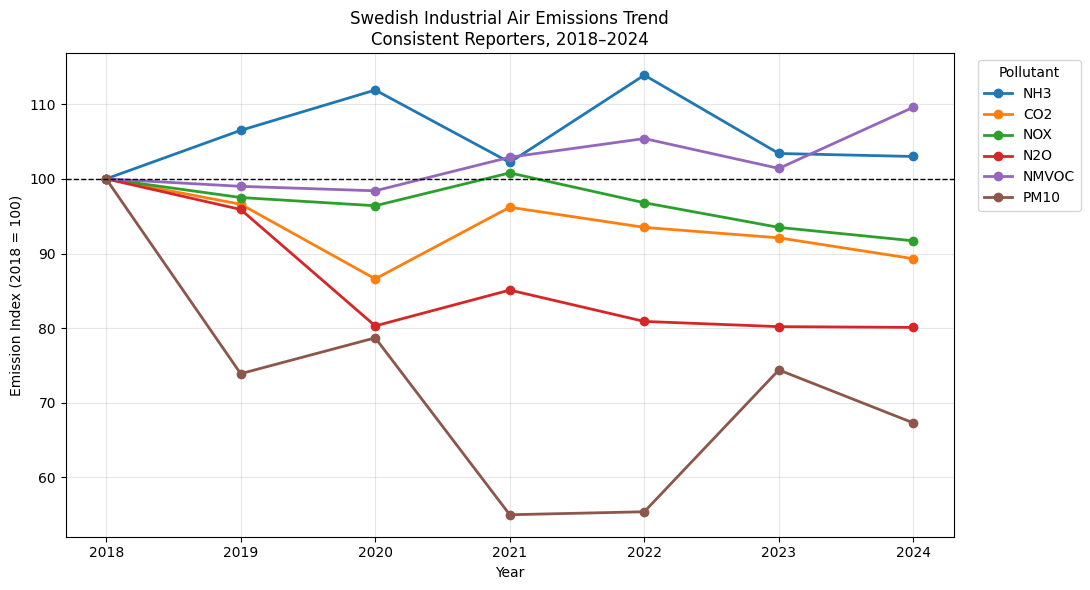

In [21]:
import matplotlib
import matplotlib.pyplot as plt

short_names = {
    "Carbon dioxide (CO2) excluding biomass": "CO2",
    "Ammonia (NH3)": "NH3",
    "Nitrogen oxides (NOX)": "NOX",
    "Nitrous oxide (N2O)": "N2O",
    "Non-methane volatile organic compounds (NMVOC)": "NMVOC",
    "Particulate matter (PM10)": "PM10"
}

plot_matrix = trend_matrix.rename(
    columns=short_names
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

for pollutant in plot_matrix.columns:
    ax.plot(
        plot_matrix.index,
        plot_matrix[pollutant],
        marker="o",
        linewidth=2,
        label=pollutant
    )

ax.axhline(
    y=100,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Swedish Industrial Air Emissions Trend\n"
    "Consistent Reporters, 2018–2024"
)

ax.set_xlabel("Year")
ax.set_ylabel("Emission Index (2018 = 100)")

ax.grid(
    alpha=0.3
)

ax.legend(
    title="Pollutant",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [22]:
output_dir = (
    Path.cwd()
    / "outputs"
    / "figures"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

figure_path = (
    output_dir
    / "emission_trend_index_2018_2024.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved to:", figure_path)
print("File exists:", figure_path.exists())

Figure saved to: /Users/zaochen/Documents/swedish_industrial_emissions_analysis/outputs/figures/emission_trend_index_2018_2024.png
File exists: True


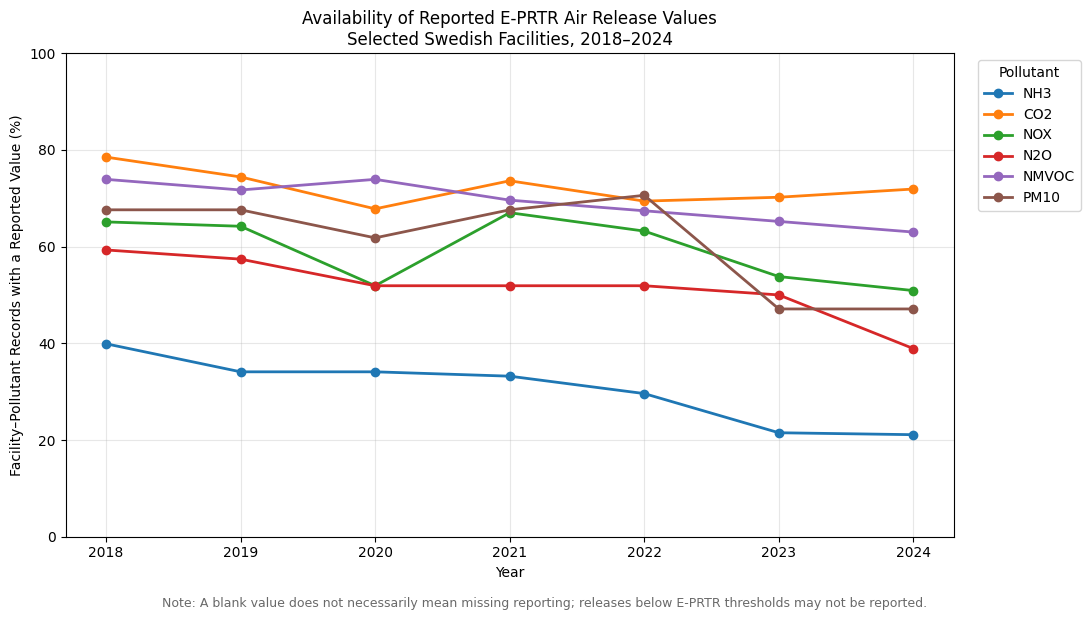

Figure saved to: /Users/zaochen/Documents/swedish_industrial_emissions_analysis/outputs/figures/reporting_coverage_2018_2024.png
File exists: True


In [23]:
coverage_plot = (
    coverage_matrix
    .rename(index=short_names)
    .T
)

fig2, ax2 = plt.subplots(
    figsize=(11, 6)
)

for pollutant in coverage_plot.columns:
    ax2.plot(
        coverage_plot.index,
        coverage_plot[pollutant],
        marker="o",
        linewidth=2,
        label=pollutant
    )

ax2.set_title(
    "Availability of Reported E-PRTR Air Release Values\n"
    "Selected Swedish Facilities, 2018–2024"
)

ax2.set_xlabel("Year")

ax2.set_ylabel(
    "Facility–Pollutant Records with a Reported Value (%)"
)

ax2.set_ylim(0, 100)

ax2.grid(
    alpha=0.3
)

ax2.legend(
    title="Pollutant",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig2.text(
    0.5,
    -0.02,
    "Note: A blank value does not necessarily mean missing reporting; "
    "releases below E-PRTR thresholds may not be reported.",
    ha="center",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()

coverage_path = (
    output_dir
    / "reporting_coverage_2018_2024.png"
)

fig2.savefig(
    coverage_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", coverage_path)
print("File exists:", coverage_path.exists())

In [24]:
annual_totals["TotalEmission_tonnes"] = (
    annual_totals["TotalEmission"]
    / 1000
)

trend_summary = (
    annual_totals
    .pivot(
        index="Pollutant",
        columns="Year",
        values="TotalEmission_tonnes"
    )[[2018, 2024]]
    .rename(
        columns={
            2018: "Emission_2018_tonnes",
            2024: "Emission_2024_tonnes"
        }
    )
)

trend_summary["Change_pct"] = (
    (
        trend_summary["Emission_2024_tonnes"]
        / trend_summary["Emission_2018_tonnes"]
        - 1
    )
    * 100
).round(1)

trend_summary["Stable_facilities"] = (
    consistent_counts
)

trend_summary = trend_summary[
    [
        "Stable_facilities",
        "Emission_2018_tonnes",
        "Emission_2024_tonnes",
        "Change_pct"
    ]
]

trend_summary

Year,Stable_facilities,Emission_2018_tonnes,Emission_2024_tonnes,Change_pct
Pollutant,,,,
Ammonia (NH3),33,1925.9,1.983692e+03,3.0
Carbon dioxide (CO2) excluding biomass,73,15333690.0,1.368977e+07,-10.7
Nitrogen oxides (NOX),50,24583.0,2.255031e+04,-8.3
Nitrous oxide (N2O),20,600.7,4.810811e+02,-19.9
Non-methane volatile organic compounds (NMVOC),27,19404.0,2.125966e+04,9.6
Particulate matter (PM10),11,2967.1,1.996792e+03,-32.7


## 6. Major CO₂-Emitting Facilities

This section ranks facilities reporting CO₂ releases in 2024 and evaluates the concentration of reported emissions among the largest emitters.

In [25]:
co2_2024 = analysis_data[
    (analysis_data["Year"] == 2024)
    & (
        analysis_data["Pollutant"]
        == "Carbon dioxide (CO2) excluding biomass"
    )
].copy()

co2_2024["Emission_tonnes"] = (
    co2_2024["Emission"]
    / 1000
)

co2_top10_2024 = (
    co2_2024
    .sort_values(
        "Emission_tonnes",
        ascending=False
    )
    .head(10)
    [
        [
            "facilityName",
            "city",
            "EPRTRAnnexIMainActivity",
            "Emission_tonnes",
            "Longitude",
            "Latitude"
        ]
    ]
    .reset_index(drop=True)
)

co2_top10_2024.insert(
    0,
    "Rank",
    range(1, len(co2_top10_2024) + 1)
)

co2_top10_2024

,Rank,facilityName,city,EPRTRAnnexIMainActivity,Emission_tonnes,Longitude,Latitude
0,1,SSAB EMEA AB i Luleå,LULEÅ,2(b),1609000.000,22.21426,65.56204
1,2,SSAB EMEA AB Oxelösund,OXELÖSUND,2(b),1468452.000,17.12562,58.67695
2,3,"Preemraff, Lysekil",LYSEKIL,1(a),1377885.347,11.42308,58.34674
3,4,"Heidelberg Materials Cement Sverige AB, Slitef...",SLITE,3(c),1251989.700,18.80539,57.71172
4,5,Luleå kraftvärmeverk LUKAB,LULEÅ,1(c),1232246.000,22.21368,65.56796
5,6,Borealis Krackeranl.,STENUNGSUND,4(a)(i),618090.630,11.82554,58.08325
6,7,St1 Refinery AB,GÖTEBORG,1(a),596401.800,11.87983,57.70185
7,8,Preem AB Preemraff Göteborg,GÖTEBORG,1(a),564263.960,11.82119,57.71094
8,9,LKAB - Kirunagruvan,KIRUNA,2(a),387098.000,20.19092,67.84939
9,10,HÖGDALENVERKET,STOCKHOLM,5(b),312863.999,18.06066,59.25761


## 7. Sector-Level CO₂ Analysis

E-PRTR activity codes are converted into broad industrial sectors. Reported 2024 CO₂ releases are then aggregated by sector.

In [26]:

co2_ranked_2024 = co2_2024.sort_values(
    "Emission_tonnes",
    ascending=False
).reset_index(drop=True)

co2_total_2024 = (
    co2_ranked_2024["Emission_tonnes"]
    .sum()
)

top1_emission = (
    co2_ranked_2024["Emission_tonnes"]
    .iloc[:1]
    .sum()
)

top5_emission = (
    co2_ranked_2024["Emission_tonnes"]
    .iloc[:5]
    .sum()
)

top10_emission = (
    co2_ranked_2024["Emission_tonnes"]
    .iloc[:10]
    .sum()
)

top1_share = (
    top1_emission
    / co2_total_2024
    * 100
)

top5_share = (
    top5_emission
    / co2_total_2024
    * 100
)

top10_share = (
    top10_emission
    / co2_total_2024
    * 100
)

print(
    f"Total reported CO2 emissions: "
    f"{co2_total_2024:,.0f} tonnes"
)

print(
    f"Top 1 share: {top1_share:.1f}%"
)

print(
    f"Top 5 share: {top5_share:.1f}%"
)

print(
    f"Top 10 share: {top10_share:.1f}%"
)

Total reported CO2 emissions: 14,147,374 tonnes
Top 1 share: 11.4%
Top 5 share: 49.1%
Top 10 share: 66.6%


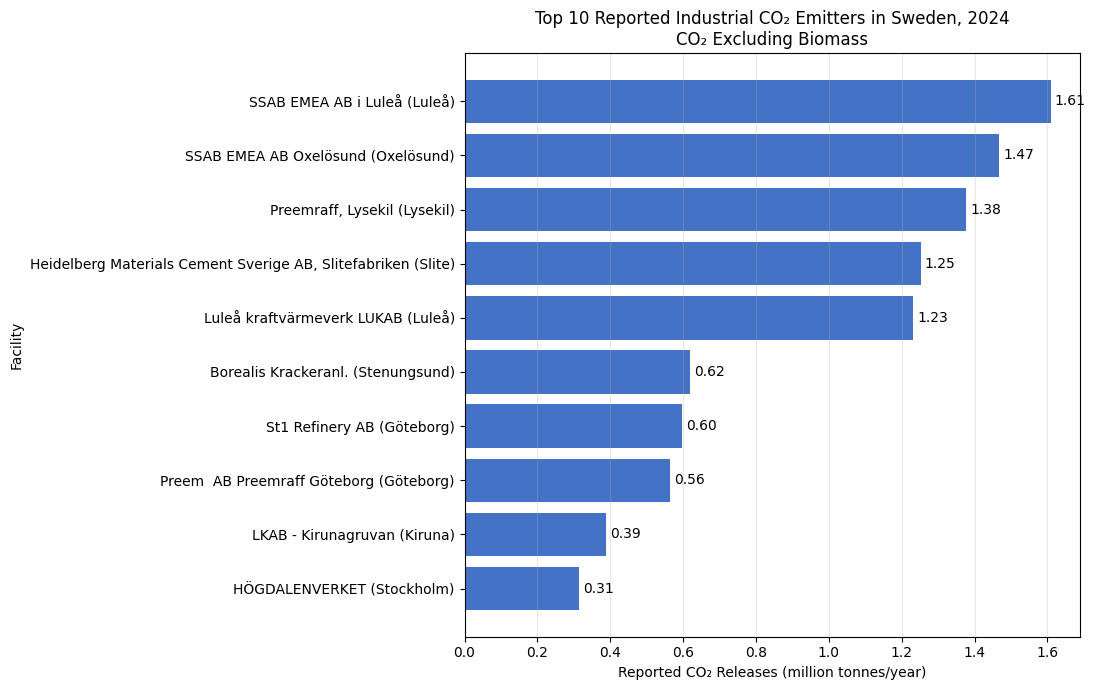

Figure saved to: /Users/zaochen/Documents/swedish_industrial_emissions_analysis/outputs/figures/top10_co2_facilities_2024.png
File exists: True


In [27]:
co2_bar = co2_top10_2024.copy()

co2_bar["Emission_Mt"] = (
    co2_bar["Emission_tonnes"]
    / 1_000_000
)

co2_bar["Label"] = (
    co2_bar["facilityName"]
    + " ("
    + co2_bar["city"].str.title()
    + ")"
)

co2_bar = co2_bar.sort_values(
    "Emission_Mt",
    ascending=True
)

fig3, ax3 = plt.subplots(
    figsize=(11, 7)
)

bars = ax3.barh(
    co2_bar["Label"],
    co2_bar["Emission_Mt"],
    color="#4472C4"
)

ax3.set_title(
    "Top 10 Reported Industrial CO₂ Emitters in Sweden, 2024\n"
    "CO₂ Excluding Biomass"
)

ax3.set_xlabel(
    "Reported CO₂ Releases (million tonnes/year)"
)

ax3.set_ylabel("Facility")

ax3.grid(
    axis="x",
    alpha=0.3
)

ax3.bar_label(
    bars,
    fmt="%.2f",
    padding=3
)

plt.tight_layout()

top10_path = (
    output_dir
    / "top10_co2_facilities_2024.png"
)

fig3.savefig(
    top10_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", top10_path)
print("File exists:", top10_path.exists())

In [28]:
sector_names = {
    "1": "Energy",
    "2": "Production and processing of metals",
    "3": "Mineral industry",
    "4": "Chemical industry",
    "5": "Waste and wastewater management",
    "6": "Paper and wood production",
    "7": "Intensive livestock and aquaculture",
    "8": "Food and beverage sector",
    "9": "Other activities"
}

co2_2024["SectorCode"] = (
    co2_2024["EPRTRAnnexIMainActivity"]
    .astype(str)
    .str.extract(
        r"^(\d+)",
        expand=False
    )
)

co2_2024["Sector"] = (
    co2_2024["SectorCode"]
    .map(sector_names)
    .fillna("Unknown")
)

print(
    co2_2024[
        [
            "EPRTRAnnexIMainActivity",
            "SectorCode",
            "Sector"
        ]
    ]
    .drop_duplicates()
    .sort_values("EPRTRAnnexIMainActivity")
)

     EPRTRAnnexIMainActivity SectorCode                               Sector
6691                    1(a)          1                               Energy
6650                    1(c)          1                               Energy
6765                    2(a)          2  Production and processing of metals
6777                    2(b)          2  Production and processing of metals
7580                 2(c)(i)          2  Production and processing of metals
7188                 2(e)(i)          2  Production and processing of metals
7614                2(e)(ii)          2  Production and processing of metals
6875                    3(b)          3                     Mineral industry
6627                    3(c)          3                     Mineral industry
7369               3(c)(iii)          3                     Mineral industry
7648                    4(a)          4                    Chemical industry
7122                 4(a)(i)          4                    Chemical industry

In [29]:
sector_summary_2024 = (
    co2_2024
    .groupby(
        "Sector",
        as_index=False
    )
    .agg(
        Facilities=(
            "FacilityInspireId",
            "nunique"
        ),
        Emission_tonnes=(
            "Emission_tonnes",
            "sum"
        )
    )
    .sort_values(
        "Emission_tonnes",
        ascending=False
    )
)

sector_summary_2024["Emission_Mt"] = (
    sector_summary_2024["Emission_tonnes"]
    / 1_000_000
)

sector_summary_2024["Share_pct"] = (
    sector_summary_2024["Emission_tonnes"]
    / sector_summary_2024["Emission_tonnes"].sum()
    * 100
).round(1)

sector_summary_2024

,Sector,Facilities,Emission_tonnes,Emission_Mt,Share_pct
1,Energy,33,5.005261e+06,5.005261,35.4
4,Production and processing of metals,10,4.590612e+06,4.590612,32.4
2,Mineral industry,5,1.933010e+06,1.933010,13.7
5,Waste and wastewater management,11,1.449550e+06,1.449550,10.2
0,Chemical industry,2,7.259026e+05,0.725903,5.1
3,Paper and wood production,26,4.430372e+05,0.443037,3.1


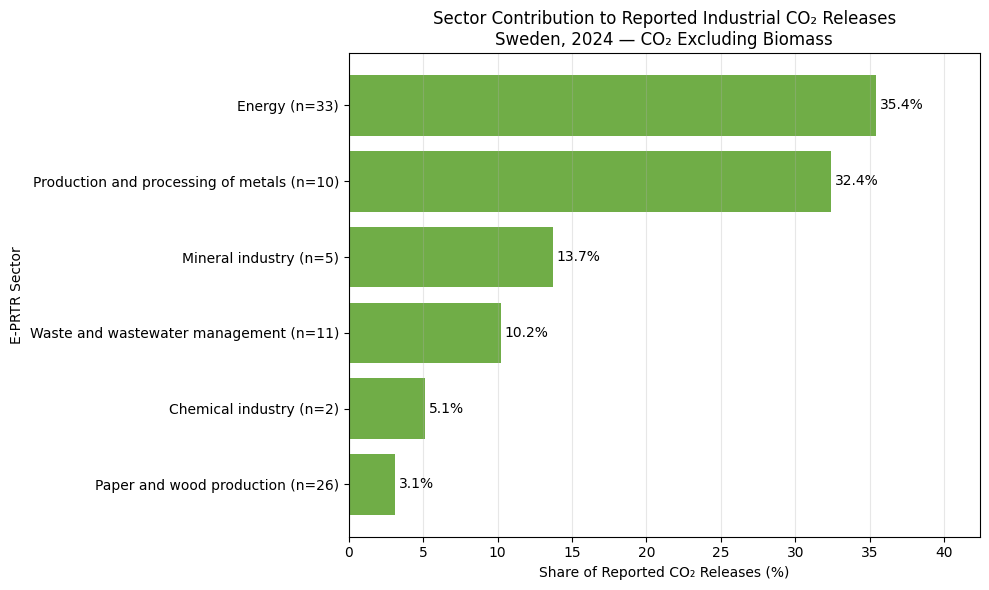

Figure saved to: /Users/zaochen/Documents/swedish_industrial_emissions_analysis/outputs/figures/co2_sector_contribution_2024.png
File exists: True


In [30]:
sector_bar = sector_summary_2024.copy()

sector_bar["Label"] = (
    sector_bar["Sector"]
    + " (n="
    + sector_bar["Facilities"].astype(str)
    + ")"
)

sector_bar = sector_bar.sort_values(
    "Share_pct",
    ascending=True
)

fig4, ax4 = plt.subplots(
    figsize=(10, 6)
)

sector_bars = ax4.barh(
    sector_bar["Label"],
    sector_bar["Share_pct"],
    color="#70AD47"
)

ax4.set_title(
    "Sector Contribution to Reported Industrial CO₂ Releases\n"
    "Sweden, 2024 — CO₂ Excluding Biomass"
)

ax4.set_xlabel(
    "Share of Reported CO₂ Releases (%)"
)

ax4.set_ylabel("E-PRTR Sector")

ax4.grid(
    axis="x",
    alpha=0.3
)

ax4.bar_label(
    sector_bars,
    fmt="%.1f%%",
    padding=3
)

ax4.set_xlim(
    0,
    sector_bar["Share_pct"].max() + 7
)

plt.tight_layout()

sector_path = (
    output_dir
    / "co2_sector_contribution_2024.png"
)

fig4.savefig(
    sector_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", sector_path)
print("File exists:", sector_path.exists())

In [31]:
map_data = co2_2024.copy()

map_data["Longitude"] = pd.to_numeric(
    map_data["Longitude"],
    errors="coerce"
)

map_data["Latitude"] = pd.to_numeric(
    map_data["Latitude"],
    errors="coerce"
)

print(
    "Total CO2 records:",
    map_data.shape[0]
)

print(
    "Missing longitude:",
    map_data["Longitude"].isna().sum()
)

print(
    "Missing latitude:",
    map_data["Latitude"].isna().sum()
)

valid_coordinates = (
    map_data["Longitude"].between(10, 25)
    & map_data["Latitude"].between(54, 70)
)

print(
    "Records within approximate Sweden bounds:",
    valid_coordinates.sum()
)

print(
    "Records outside bounds or missing:",
    (~valid_coordinates).sum()
)

Total CO2 records: 87
Missing longitude: 0
Missing latitude: 0
Records within approximate Sweden bounds: 87
Records outside bounds or missing: 0


## 8. Spatial Distribution

Facility coordinates are validated and used to create an interactive Plotly map of reported industrial CO₂ releases in Sweden.

In [32]:
import plotly
import plotly.express as px



In [33]:
map_data["Emission_Mt"] = (
    map_data["Emission_tonnes"]
    / 1_000_000
)

fig5 = px.scatter_geo(
    map_data,
    lat="Latitude",
    lon="Longitude",
    size="Emission_Mt",
    color="Sector",
    hover_name="facilityName",
    hover_data={
        "city": True,
        "Emission_Mt": ":.3f",
        "EPRTRAnnexIMainActivity": True,
        "Latitude": False,
        "Longitude": False
    },
    size_max=35,
    projection="mercator",
    title=(
        "Reported Industrial CO₂ Releases in Sweden, 2024"
        "<br><sup>CO₂ excluding biomass; bubble size represents "
        "reported releases</sup>"
    )
)

fig5.update_geos(
    fitbounds="locations",
    showland=True,
    landcolor="#F2F2F2",
    showocean=True,
    oceancolor="#DDEBF7",
    showcountries=True,
    countrycolor="#808080",
    showcoastlines=True,
    coastlinecolor="#808080"
)

fig5.update_layout(
    height=750,
    legend_title_text="E-PRTR Sector",
    margin={
        "l": 20,
        "r": 20,
        "t": 90,
        "b": 20
    }
)

fig5.show()

## 9. Exporting Results

Final figures, tables, and the interactive map are exported to the `outputs` directory.

In [34]:
interactive_dir = (
    Path.cwd()
    / "outputs"
    / "interactive"
)

interactive_dir.mkdir(
    parents=True,
    exist_ok=True
)

map_html_path = (
    interactive_dir
    / "sweden_co2_facilities_2024.html"
)

fig5.write_html(
    map_html_path,
    include_plotlyjs=True,
    full_html=True
)

print(
    "Interactive map saved to:",
    map_html_path
)

print(
    "File exists:",
    map_html_path.exists()
)

print(
    "File size:",
    round(
        map_html_path.stat().st_size
        / 1_000_000,
        2
    ),
    "MB"
)

Interactive map saved to: /Users/zaochen/Documents/swedish_industrial_emissions_analysis/outputs/interactive/sweden_co2_facilities_2024.html
File exists: True
File size: 4.32 MB


In [35]:
tables_dir = (
    Path.cwd()
    / "outputs"
    / "tables"
)

tables_dir.mkdir(
    parents=True,
    exist_ok=True
)

availability_by_pollutant = (
    pollutant_year_quality
    .rename(
        columns={
            "reporting_rate_pct":
            "value_availability_pct"
        }
    )
)

annual_totals.to_csv(
    tables_dir / "annual_emission_trends.csv",
    index=False
)

trend_summary.reset_index().to_csv(
    tables_dir / "trend_summary_2018_2024.csv",
    index=False
)

availability_by_pollutant.to_csv(
    tables_dir / "reported_value_availability.csv",
    index=False
)

co2_top10_2024.to_csv(
    tables_dir / "top10_co2_facilities_2024.csv",
    index=False
)

sector_summary_2024.to_csv(
    tables_dir / "co2_sector_summary_2024.csv",
    index=False
)

print("Saved table files:")

for file_path in sorted(
    tables_dir.glob("*.csv")
):
    print(
        "-",
        file_path.name,
        "|",
        round(
            file_path.stat().st_size / 1000,
            1
        ),
        "KB"
    )

Saved table files:
- annual_emission_trends.csv | 2.5 KB
- co2_sector_summary_2024.csv | 0.4 KB
- reported_value_availability.csv | 1.9 KB
- top10_co2_facilities_2024.csv | 0.8 KB
- trend_summary_2018_2024.csv | 0.4 KB


## 10. FAIR data principles

### Findable
The workflow is hosted in a public GitHub repository which can be find through some keywords, and this workflow is described by a README file containing the project title, research questiones, data source, methodology, and mian outputs.

### Accessible

The original E-PRTR dataset is not stored directly in this repository. Instead, `DATA.md` documents the data source and provides instructions for obtaining the original data from the European Environment Agency. This documentation are publicly accessible through the GitHub repository without requiring authentication.

### Interoperable

The workflow uses supported and machine-readable data formats. Results are exported as CSV files, which can be opened and processed by many different tools and programming languages.

### Reusable
The repository provides all the information to make the workflow easier to understand and reuse. And this project is released under the MIT License, which clealy defines how the code can be used, modified, and redistributed.